# GEOG5990M Portfolio assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
###  COURSEWORK COVERSHEET
- Student ID number: 201977905
- Module code: 25/26(2) GEOG5990M
- Module title: Programming for Geographical Information Analysis: Core Skills (28787)
- Assignment title: Portfolio assignment
- Marker:
- Declared word count: 161 (Block1), 250 (Block2)


#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate

- I have used Gen AI only for the specific purposes outlined in my acknowledgements


By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

## Block One Submission
Using data introduced in the course create a visualisation showing the association between two variables. Using skills developed in the practical exercises take any steps required to clean or pre-process the data.  It is expected that you wills change the default appearance of the markers and include an appropriate title and axis labels. Further marks will be awarded for appropriate use of colour pallets, inclusion of additional categorical variables in the visualisation and other steps taken to ensure effective data visualisation.

Ensure all the code has detialed comments.

Write a brief paragraph in markdown (max. 300 words) detailing the visualisation choices made given the types of data you have chosen.

In [9]:
#1. Import required packages

#1.1 Import pandas and numpy for efficient data manipulation and numerical computation
import pandas as pd
import numpy as np

#1.2 Import matplotlib and seaborn for data visualization and statistical plotting
import matplotlib.pyplot as plt
import seaborn as sns

#1.3 Import geopandas for analyzing geospatial data
import geopandas as gpd

#1.4 Import warnings and suppress unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

#1.5 Set the default background style of all seaborn charts to a clean white grid
sns.set_theme(style="whitegrid")

In [10]:
#2. Data-preprocessing

# # Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-19)
# The following prompt was used in Gemini to debug when I encountered a 'ParserError' when reading the CSV file：
# [Why can't the file be read? How should the URL be modified?]
# The repsonse generated was use to help generate the code below (2.1)

#2.1 Read data from the original link of GitHub and save it as a table
titanic_df = pd.read_csv('https://github.com/FrancescaPontin/GEOG5990M/raw/refs/heads/main/data/week_14/titanic.csv')

#2.2 Check missing values for all columns to assess data quality
print(titanic_df.isnull().sum())

#2.3 Select columns that are valuable for researching 'Class and Survival'
selected_cols = ['class', 'fare', 'survived', 'embark_town']
# And create a new dataframe with selected columns
plot_data = titanic_df[selected_cols]

#2.4 Drop rows with missing values
plot_data = plot_data.dropna()

#2.5 Visually inspect the cleaned data
display(plot_data)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,class,fare,survived,embark_town
0,Third,7.2500,0,Southampton
1,First,71.2833,1,Cherbourg
2,Third,7.9250,1,Southampton
3,First,53.1000,1,Southampton
4,Third,8.0500,0,Southampton
...,...,...,...,...
886,Second,13.0000,0,Southampton
887,First,30.0000,1,Southampton
888,Third,23.4500,0,Southampton
889,First,30.0000,1,Cherbourg


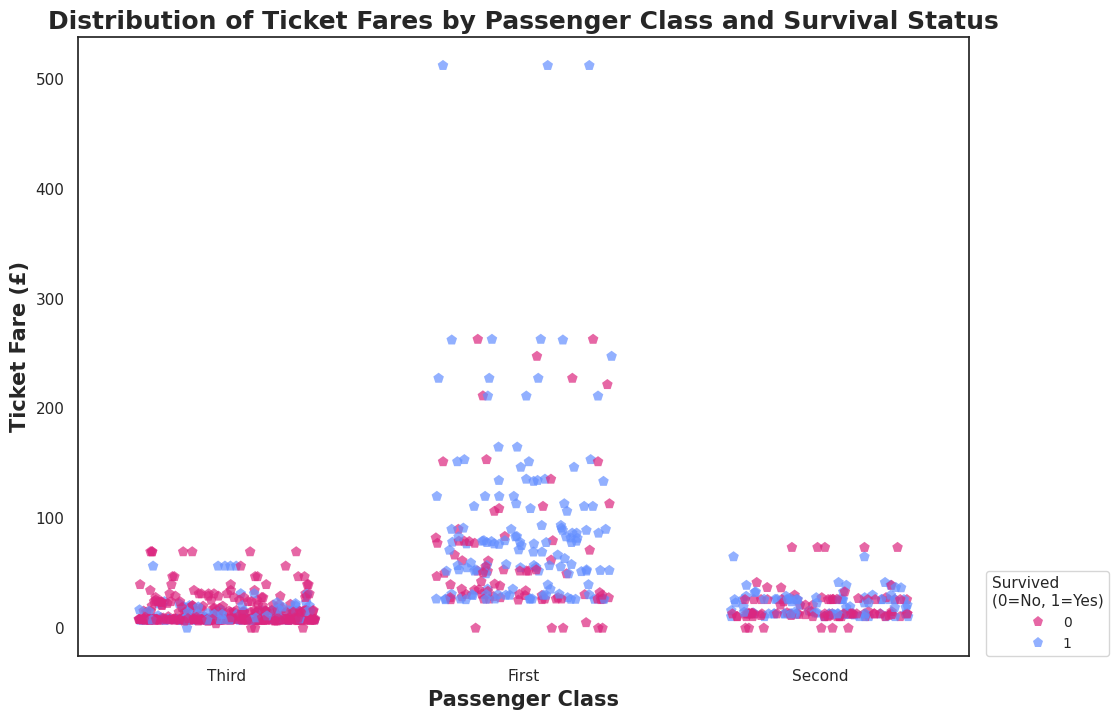

In [11]:
#3. Data visualisation

#3.1 Set seaborn plotting theme to white
sns.set_theme(style="white")

#3.2 Create a blank canvas and an axis with a size of 12x8 inches
f, ax = plt.subplots(1, figsize=(12, 8))
# And define custom colors that 0 (Not Survived) is pinkish-red, 1 (Survived) is blue
my_palette = {0: "#DC267F", 1: "#648FFF"}

#3.3 Plot a stripplot to show the distribution of fares by class and survival
sns.stripplot(
  data=plot_data,     # ues the cleaned dataset
  x='class',        # put passenger class on the X-axis
  y='fare',        # put ticket fare on the Y-axis
  hue='survived',     # color the points differently based on survival status
  palette=my_palette,   # apply the custom colors
  jitter=0.3,       # spread the dots out horizontally so they don't overlap too much
  alpha=0.7,        # make points slightly transparent so overlapping areas look darker
  size=8,         # set the size of each data point
  marker="p",       # change the shape of the dots to a pentagon
  ax=ax          # draw this plot onto the created 12x8 canvas
)

#3.4 Add title and change default axis labels
ax.set_title('Distribution of Ticket Fares by Passenger Class and Survival Status',
      fontsize=18, fontweight='bold')  # add a bold main title to the plot with a larger font size
ax.set_xlabel('Passenger Class',
      fontsize=15, fontweight='bold')  # rename the X-axis label
ax.set_ylabel('Ticket Fare (£)',
      fontsize=15, fontweight='bold')  # rename the Y-axis label


# # Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-19)
# The following prompt was used in Gemini to set the position of legend：
# [Generate the code to position the legend on the lower right side]
# The repsonse generated was use to help generate the code below (3.5)

#3.5 Position legend outside the plot
ax.legend(
    title='Survived\n(0=No, 1=Yes)',   # add a title to the legend
    fontsize=10,              # set the text size of the legend items
    title_fontsize=11,           # set the text size of the legend title
    bbox_to_anchor=(1.02, 0),       # push the anchor point completely outside the right edge of the plot
    loc='lower left',           # align the lower-left corner of the legend to the anchor point
    borderaxespad=0            # remove extra spacing between the legend and the plot axis
)

#3.6 Adjust the frame and show the plot
plt.tight_layout(pad=3.0)   # automatically adjust margins
plt.show()

### Block One Submission
Does social status affect survival rates in major accidents? In the data-preprocessing stage, I selected variables including "class", "fare", and "survival status", and also extracted the "embark_town" column. I used the "dropna()" to remove two rows of missing data, ensuring the completeness and validity of the data.

For data visualisation, I chose a stripplot as the main visualisation tool, which clearly demonstrates the distribution of a continuous variable (fare) across different categorical groups (class). By using two highly contrasting colours (#DC267F and #648FFF) as another categorical variable (survival status), the colour distribution ratio directly confirms a higher density of survivors among upper-class passengers.

Regarding the detailed settings of the stripplot, I changed the default circular markers to pentagon (marker="p") and added transparency (alpha=0.7) to reduce overlap. I also set axis names that describe the variables. Additionally, I moved the legend outside the main axis and applied tight_layout(pad=3.0) to ensure no data points were obscured, resulting in a clean and professional chart.










    

#### Block 1 Bibliography

## Block Two Submission:

Using the course notebooks and lectures as a guide create a static visualisation showing the spatial distribution of a variable of your choice. The type of spatial visualisation chosen should be suitable for the data chosen and appropriate data cleaning and pre-processing steps undertaken. Using skills demonstrated in the python notebooks change the default appearance of the visualisation of choice. Include an appropriate title and legend labels. Further marks will be awarded for appropriate use of colour pallets and other customisations to aid interpretation and improve accessibility. Write a brief paragraph in markdown (max 300 words) detailing the visual design choices made.

In [ ]:
#1. Import any further required packages

#1.1 Install additional spatial packages for basemaps and advanced map classification
# But run only once if the packages are not installed
!pip install contextily
!pip install mapclassify

In [12]:
#1.2 Import pandas for efficient data manipulation
import pandas as pd

#1.3 Import matplotlib for data visualization
import matplotlib.pyplot as plt

#1.4 Import geopandas for analyzing geospatial data
import geopandas as gpd

#1.5 Import contextily for adding a basemap
import contextily as ctx

#1.6 Import warnings and suppress unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

# # Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-22)
# The following prompt was used in Gemini to customize and combine the map legends:
# [I want to add the Leeds boundary and bus stops into the same legend box. How can I do this?]
# The response generated was used to help generate the custom legend using Line2D (1.7)

#1.7 Import a tool for creating custom legend items
from matplotlib.lines import Line2D

In [13]:
#2. Data-preprocessing

#2.1 Read data from the original link of GitHub and save them as tables
leeds_gdf = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M/raw/refs/heads/main/data/week_6_7/leeds_travel_to_work_mode_distance.geojson')
leeds_boundary = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M/raw/refs/heads/main/data/week_6_7/Leeds.geojson')
bus_stops = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M/raw/refs/heads/main/data/week_6_7/West_Yorkshire_bus_stops.geojson')
leeds_pop = pd.read_csv('https://github.com/FrancescaPontin/GEOG5990M/raw/refs/heads/main/data/week_6_7/lsoa_resident_pop.csv')

#2.2 Make sure all spatial layers to British National Grid (EPSG:27700)
leeds_gdf = leeds_gdf.to_crs(epsg=27700)
leeds_boundary = leeds_boundary.to_crs(epsg=27700)
bus_stops = bus_stops.to_crs(epsg=27700)

# # Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-22)
# The following prompt was used in Gemini to resolve a KeyError during data merging:
# [I got a "KeyError: 'lsoa11cd'" when merging a GeoJSON and a CSV file. The LSOA ID column names are different (e.g., 'LSOA21CD' vs 'geography code') and might change. How can I dynamically find the correct ID column and merge them?]
# The response generated was used to help generate the dynamic column identification and merge code below (2.3)

#2.3 Dynamically identify columns and merge population data
# Use a loop to find the exact name of the LSOA ID column
id_col = [c for c in leeds_gdf.columns if 'LSOA' in c.upper() and 'CD' in c.upper()][0]
# Locate the column containing the word 'Bus' for our commuter numbers
bus_col = [c for c in leeds_gdf.columns if 'Bus' in c][0]
# Specify the exact column name for the total population
pop_col = 'Residence type: Total; measures: Value'

#2.4 Attribute spatial join
# Merge the spatial map data with the population table using the ID columns as the bridge
leeds_combined = leeds_gdf.merge(
    leeds_pop,
    left_on=id_col,
    right_on='geography code',
    how='left'
)

#2.5 Calculate the regional public transport commuting rate by normalising the data
leeds_combined['bus_rate'] = (leeds_combined[bus_col] / leeds_combined[pop_col]) * 100

#2.6 Perform spatial clip of Leeds bus stops from the Yorkshire bus stops
leeds_bus_stops = gpd.clip(bus_stops, leeds_boundary)

#2.7 Check the geographic coordinate system and the merged table
print(leeds_combined.crs)
display(leeds_combined[[id_col, bus_col, 'bus_rate']].head())

EPSG:27700


,LSOA21CD,"Bus, minibus or coach",bus_rate
0,E01011264,25,1.947040
1,E01011265,17,0.869565
2,E01011266,13,0.497512
3,E01011267,15,0.882872
4,E01011268,35,2.508961


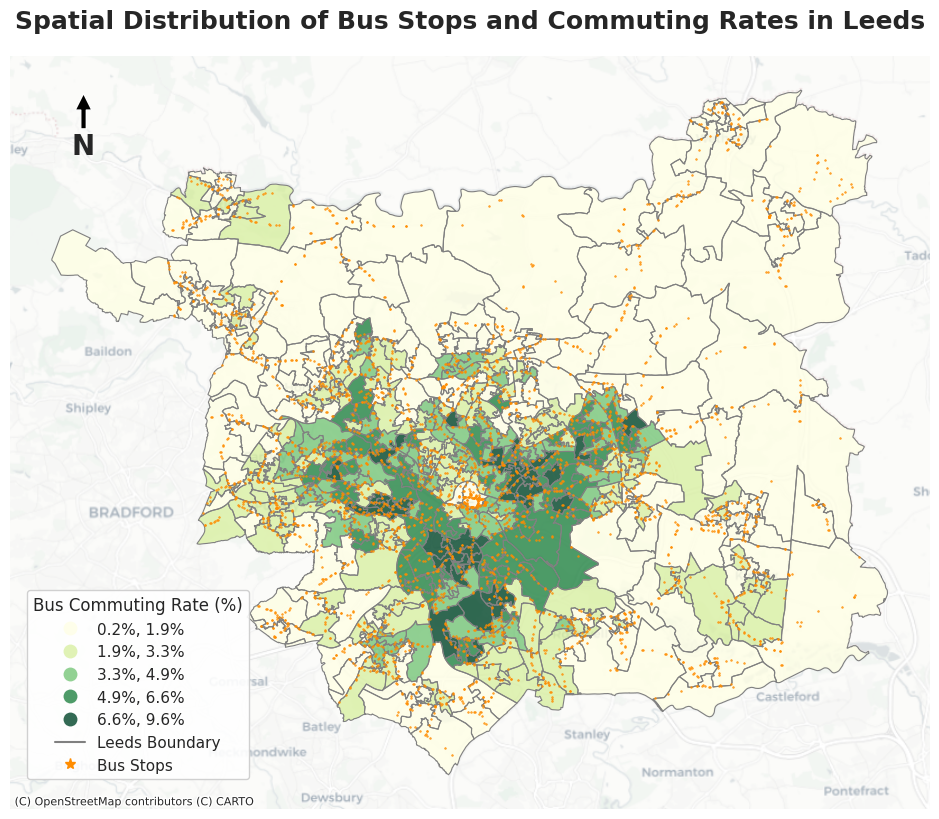

In [14]:
#3. Data Visualisation

#3.1 Create a blank canvas and an axis with a size of 12x9 inches
f, ax = plt.subplots(1, figsize=(12, 9))

#3.2 Plot the choropleth map of bus commuting rate in Leeds
leeds_combined.plot(
    column='bus_rate',     # color the map based on the commuting rate
    scheme='NaturalBreaks',   # use NaturealBreaks as the classification method
    k=5,            # divide the data into 5 color classes
    cmap='YlGn',        # use a Yellow-to-Green colormap
    legend=True,        # turn on the legend
    alpha=0.8,         # make the map 80% opaque
    edgecolor='white',     # add thin white borders between LSOAs to make individual areas stand out clearly
    linewidth=0.1,
    legend_kwds={'title': "Bus Commuting Rate (%)", 'loc': 'lower left', 'fmt': "{:.1f}%"}, # format legend numbers to 1 decimal place
    ax=ax
)

#3.3 Plot the Leeds boundary
# Draw a hollow polygon with just a grey outline to clearly define the city borders
leeds_boundary.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.8)

#3.4 Plot bus stops
leeds_bus_stops.plot(
    ax=ax,
    marker='*',     # use star shape to demonstrate bus stops
    color='#FF8C00',   # dark orange for visibility against the green background
    markersize=0.8,   # set a suitable markersize and transparency
    alpha=0.7
)

#3.5 Add a basemap using contextily
ctx.add_basemap(
    ax,
    crs=leeds_combined.crs.to_string(),   # ensure the basemap aligns with our EPSG:27700 data
    source=ctx.providers.CartoDB.Positron,
    alpha=0.8
)

# Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-22)
# The following prompt was used in Gemini to create a north arrow without external dependencies:
# [I haven't downloaded geo_northarrow.py, is there another way to customize a north arrow?]
# The response generated was used to help generate the custom north arrow annotation code below (3.6)

#3.6 Add a north arrow
# Use the annotation tool to draw a bold 'N' with an arrow pointing up
ax.annotate('N', xy=(0.08, 0.95), xytext=(0.08, 0.88),   # positioned dynamically at the top left (8% from left, 95% from bottom)
      arrowprops=dict(facecolor='black', width=4, headwidth=12),
      ha='center', va='center', fontsize=20, fontweight='bold',
      xycoords='axes fraction', textcoords='axes fraction')

# Code generated with the support of Gemini 3.1 Pro （Google, https://gemini.google.com/app Accessed 2026-3-22)
# The following prompt was used in Gemini to interact with matplotlib legend objects:
# [How do I use Python to get the current legend from an axis (ax) and extract all its texts and color blocks into lists?]
# The response generated was used to help generate the legend extraction code below (3.7)

#3.7 Extract the existing legend created by geopandas
leg = ax.get_legend()                  # retrieve the current legend object from the matplotlib axis
handles = leg.legend_handles               # extract the list of visual elements from the legend
labels = [t.get_text() for t in leg.get_texts()]   # extract the text labels corresponding to each handle using a list comprehension
title = leg.get_title().get_text()            # get the title text of the existing legend to retain it for the new legend

#3.8 Create custom legend for the boundary and bus stops
boundary_line = Line2D([0], [0], color='grey', lw=1.5)                     # create a Line2D object to represent the Leeds boundary line in the legend
bus_marker = Line2D([0], [0], marker='*', color='#FF8C00', linestyle='None', markersize=8)  # create a Line2D object with a marker to represent bus stops in the legend

#3.9 Add them to the existing handles and labels
handles.extend([boundary_line, bus_marker])     # append the custom boundary and bus stop handles to the existing handles list
labels.extend(['Leeds Boundary', 'Bus Stops'])   # append the corresponding text strings to the labels list

#3.10 Re-draw the combined legend in the lower left
ax.legend(
    handles,               # apply the combined list of visual elements
    labels,                # apply the combined list of text labels
    loc='lower left',          # set the alignment of the legend box
    bbox_to_anchor=(0.01, 0.03),     # define exact coordinates for the anchor point to avoid overlapping
    title=title,             # apply the extracted original title
    frameon=True,             # enable the border frame of the legend box
    facecolor='white',          # set the background color to white
    framealpha=0.9)            # set the opacity of the background to 0.9

#3.11 Add a bold title with a larger font size
ax.set_title('Spatial Distribution of Bus Stops and Commuting Rates in Leeds',
      fontsize=18, fontweight='bold', pad=20)
# And the coordinate axes can be hidden because it is a thematic map
ax.set_axis_off()

#3.12 Adjust the frame and show the map
plt.tight_layout(pad=3.0)   # automatically adjust margins
plt.show()

### Block Two Submission
Does the spatial distribution of bus infrastructure determine how much Leeds residents rely on public transport? This study uses a choropleth map to show the proportion of bus commuters and the distribution of bus stops in Leeds.

In the data-preprocessing stage, I reprojected all datasets to the British National Grid (EPSG:27700). Then, I used the LSOA code as a unique key to perform an attribute join. This step merged the spatial geometry layer with the non-spatial census CSV table to spatialize the population data.

A simple population density map lacks analytical precision. Therefore, I divided the absolute number of bus commuters by the total resident population. This calculation created normalized data for the bus commuting rate (bus_rate). I also clipped the bus stops using the Leeds administrative boundary to focus strictly on the study area.

For data visualisation, I applied the Jenks Natural Breaks method to map the commuting rates. This method maximizes inter-class variance and scientifically reveals clusters of high and low bus dependency. I chose an intuitive 'Yellow-Green' (YlGn) color gradient. Darker areas represent a higher bus dependency. Additionally, I overlaid high-contrast orange markers to show the bus stops. I also used a dark grey outline to draw the Leeds administrative boundary. Finally, I added a Contextily street basemap for geographic context. I used Matplotlib proxy artists to combine the polygon, line, and point layers into a single legend in the lower-left corner, and added a custom north arrow. Finally, a multi-level display thematic research map is generated.





#### Block 2 Bibliography

## Gen AI use acknowledgement

I acknowledge the use of Gemini - 3.1 Pro (Google, https://gemini.google.com/app) to support the development of code for troubleshooting data preprocessing errors and enhancing advanced cartographic visualisations. Specifically, in Block 1, the AI assisted in debugging a CSV URL ParserError (2.1) and provided the solution to correctly position the map legend (3.5). In Block 2, Gemini was utilised to help generate custom proxy artists using Line2D for legend customization (1.7) and to resolve a data-merging KeyError by generating logic to dynamically identify LSOA ID columns (2.3). Furthermore, it supported the creation of a standalone north arrow using built-in annotations without external dependencies (3.6) and provided the method to extract existing Matplotlib legend objects, enabling the seamless integration of multiple map elements into a single cohesive legend box (3.7).





## References
<p><a href="add_url_here">[1] </a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2] </a>GEOG5990M course materials</p>
<p><a href="https://doi.org/10.1186/s40163-020-00121-w">[3] </a>Halford, E., Dixon, A., Farrell, G., Malleson, N. and Tilley, N., 2020. Crime and coronavirus: Social distancing, lockdown, and the mobility elasticity of crime. Crime science, 9(1), p.11</p>